# Kerr Black-Hole Raytracer

Final renders for Phase 6: spin-dependent shadow shape (frame dragging
shifts and deforms it, unlike Schwarzschild's perfectly circular
shadow), a full lensed-accretion-disk scene, and a prograde-vs
-retrograde disk comparison showing the spin-dependent ISCO directly.
See `Kerr_Raytracer_Plan.md` for the physics/design and `Geodesic
Validation.ipynb` for the geodesic-integrator validation this all rests
on. All figures saved to `media/`.

In [1]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt

import metric
import geodesics
import camera
import scene
import raytrace

MEDIA = "media"
os.makedirs(MEDIA, exist_ok=True)

M = metric.M_DEFAULT
for a in [0.0, 0.5, 0.9, 0.998]:
    r_h = metric.r_horizon(a, M)
    r_ph_pro = metric.r_photon_sphere(a, M, prograde=True)
    r_ph_ret = metric.r_photon_sphere(a, M, prograde=False)
    r_isco_pro = metric.r_isco(a, M, prograde=True)
    r_isco_ret = metric.r_isco(a, M, prograde=False)
    print(f"a={a:5.3f}  r_horizon={r_h:.4f}  "
          f"photon sphere pro/retro={r_ph_pro:.4f}/{r_ph_ret:.4f}  "
          f"ISCO pro/retro={r_isco_pro:.4f}/{r_isco_ret:.4f}")

a=0.000  r_horizon=2.0000  photon sphere pro/retro=3.0000/3.0000  ISCO pro/retro=6.0000/6.0000
a=0.500  r_horizon=1.8660  photon sphere pro/retro=2.3473/3.5321  ISCO pro/retro=4.2330/7.5546
a=0.900  r_horizon=1.4359  photon sphere pro/retro=1.5579/3.9103  ISCO pro/retro=2.3209/8.7174
a=0.998  r_horizon=1.0632  photon sphere pro/retro=1.0739/3.9982  ISCO pro/retro=1.2370/8.9944


## 0. Sanity check: `render` (per-pixel, adaptive) vs. `render_fast` (vectorized, fixed-step)

`raytrace.py`'s docstring flags that `render_fast` should be
cross-checked against `render` before it's trusted -- this is that
check, made a first-class, repo-visible cell rather than left in scratch
testing. (This is also where the real bug documented in
`Kerr_Raytracer_Plan.md`'s Phase 5 entry was found: the initial default
step `h=1e-2` was too coarse and diverged for rays near the critical
impact parameter. `h=1e-3`, the module default, is what's checked here.)

C:\Users\Hasan's Laptop\OneDrive\Projects\Physics Simulations\General_Relativity\Kerr_Raytracer\geodesics.py:42: RuntimeWarning: overflow encountered in square
  return E * (r**2 + a**2) - a * Lz
C:\Users\Hasan's Laptop\OneDrive\Projects\Physics Simulations\General_Relativity\Kerr_Raytracer\metric.py:28: RuntimeWarning: overflow encountered in square
  return r**2 - 2.0 * M * r + a**2
C:\Users\Hasan's Laptop\OneDrive\Projects\Physics Simulations\General_Relativity\Kerr_Raytracer\geodesics.py:70: RuntimeWarning: invalid value encountered in divide
  return -(a * E - Lz / s**2) + a * _P(r, E, Lz, a) / metric.Delta(r, a, M)


render: 52.3s   render_fast: 1.77s   speedup: 30x
mean abs pixel diff: 4.64e-04   fraction of pixels differing by >0.05: 0.0008


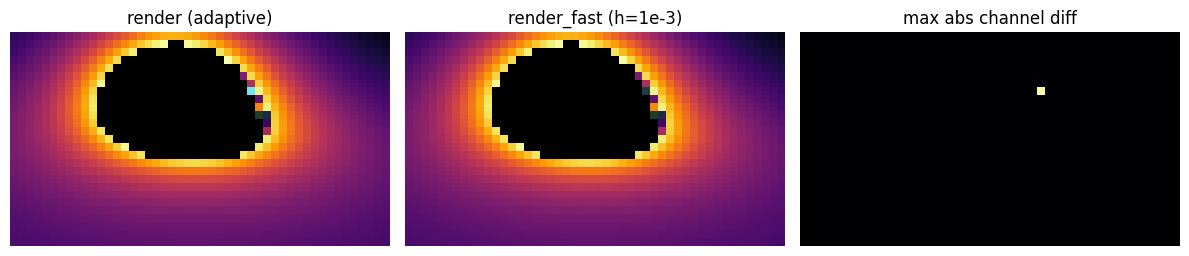

PASS: render_fast matches render except for isolated shadow-boundary pixels.


In [2]:
a_check = 0.9
r_cam_check, theta_cam_check = 15.0, 1.2
res_check = (48, 27)

t0 = time.time()
img_slow = raytrace.render(res_check, r_cam_check, theta_cam_check, 0.0, a_check, tau_max=500.0, max_step=2e-2)
t1 = time.time()
img_fast = raytrace.render_fast(res_check, r_cam_check, theta_cam_check, 0.0, a_check)
t2 = time.time()

diff = np.abs(img_slow - img_fast)
frac_bad = (diff.max(axis=-1) > 0.05).mean()
print(f"render: {t1-t0:.1f}s   render_fast: {t2-t1:.2f}s   speedup: {(t1-t0)/(t2-t1):.0f}x")
print(f"mean abs pixel diff: {diff.mean():.2e}   fraction of pixels differing by >0.05: {frac_bad:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img_slow); axes[0].set_title("render (adaptive)")
axes[1].imshow(img_fast); axes[1].set_title("render_fast (h=1e-3)")
axes[2].imshow(diff.max(axis=-1), cmap="inferno"); axes[2].set_title("max abs channel diff")
for ax in axes:
    ax.axis("off")
fig.tight_layout()
fig.savefig(os.path.join(MEDIA, "render_vs_render_fast.png"), dpi=150, bbox_inches="tight")
plt.show()

assert frac_bad < 0.01, "render_fast should match render almost everywhere at this resolution"
print("PASS: render_fast matches render except for isolated shadow-boundary pixels.")

## 1. Spin sweep: the shadow shrinks *and* shifts as spin increases

A Schwarzschild shadow (`a=0`) is a perfect circle centered on the black
hole. As `a` increases, frame dragging makes the shadow shrink overall
and become visibly asymmetric/D-shaped, offset toward the retrograde
side of the image -- this is the single most distinctive Kerr-vs
-Schwarzschild visual signature, and a direct consequence of the
prograde/retrograde photon-sphere split computed in `metric.py` (Phase
1) and validated in `Geodesic Validation.ipynb` (Phase 2). Equatorial
camera, no disk, so the pure lensing/shadow shape is unobstructed.

C:\Users\Hasan's Laptop\OneDrive\Projects\Physics Simulations\General_Relativity\Kerr_Raytracer\geodesics.py:70: RuntimeWarning: invalid value encountered in multiply
  return -(a * E - Lz / s**2) + a * _P(r, E, Lz, a) / metric.Delta(r, a, M)
C:\Users\Hasan's Laptop\OneDrive\Projects\Physics Simulations\General_Relativity\Kerr_Raytracer\geodesics.py:60: RuntimeWarning: overflow encountered in multiply
  return 4.0 * E * r * _P(r, E, Lz, a) - 2.0 * (r - M) * K


a=0.0: rendered in 16.4s


a=0.5: rendered in 23.1s


a=0.9: rendered in 35.6s


a=0.998: rendered in 53.7s


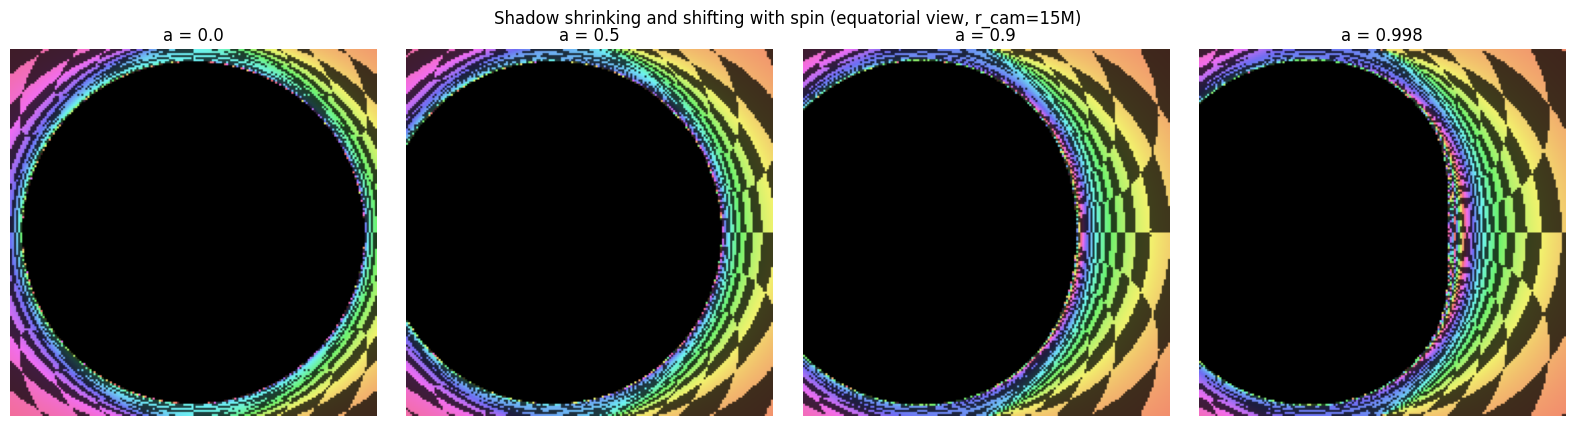

In [3]:
spins = [0.0, 0.5, 0.9, 0.998]
res_shadow = (180, 180)
r_cam_shadow, fov_shadow = 15.0, 40.0

shadow_imgs = []
for a in spins:
    t0 = time.time()
    img = raytrace.render_fast(res_shadow, r_cam_shadow, np.pi / 2, 0.0, a,
                                disk=False, fov_deg=fov_shadow, tau_max=80.0)
    shadow_imgs.append(img)
    print(f"a={a}: rendered in {time.time()-t0:.1f}s")

fig, axes = plt.subplots(1, 4, figsize=(16, 4.3))
for ax, a, img in zip(axes, spins, shadow_imgs):
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"a = {a}")
fig.suptitle("Shadow shrinking and shifting with spin (equatorial view, r_cam=15M)")
fig.tight_layout()
fig.savefig(os.path.join(MEDIA, "shadow_spin_sweep.png"), dpi=150, bbox_inches="tight")
plt.show()

## 2. Full scene: lensed accretion disk at high spin

Camera looking down at the disk from a shallow angle (`theta_cam=80deg`
from the pole, 10deg above the disk plane, matching
`Schwarzschild_Raytracer`'s own Phase 6 shot for a direct visual
comparison), `a=0.9`, disk between the spin- and prograde-dependent ISCO
and `r_out=20M`.

rendered in 125.5s


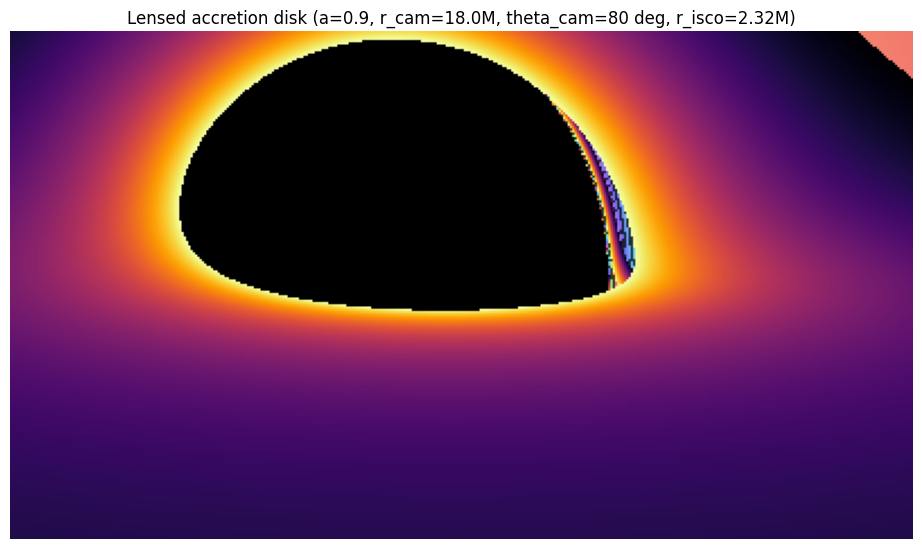

In [4]:
a_disk = 0.9
r_cam_disk = 18.0
theta_cam_disk = np.radians(80)
res_disk = (400, 225)

t0 = time.time()
img_disk = raytrace.render_fast(res_disk, r_cam_disk, theta_cam_disk, 0.0, a_disk,
                                 disk=True, fov_deg=50.0, tau_max=150.0)
print(f"rendered in {time.time()-t0:.1f}s")

fig, ax = plt.subplots(figsize=(10, 5.6))
ax.imshow(img_disk)
ax.axis("off")
r_isco_disk = metric.r_isco(a_disk, M, prograde=True)
ax.set_title(f"Lensed accretion disk (a={a_disk}, r_cam={r_cam_disk}M, "
             f"theta_cam={np.degrees(theta_cam_disk):.0f} deg, r_isco={r_isco_disk:.2f}M)")
fig.tight_layout()
fig.savefig(os.path.join(MEDIA, "render_with_disk.png"), dpi=150, bbox_inches="tight")
plt.show()

## 3. Prograde vs. retrograde disk: the ISCO split, visually

Phase 1 computed a large ISCO split at `a=0.9`: prograde `2.32M` vs.
retrograde `8.72M`. A prograde disk can therefore orbit much closer to
the hole (bigger, brighter inner region) than a retrograde one -- same
camera and spin, only the disk's sense of rotation (and therefore its
inner edge, via `metric.r_isco(a, M, prograde=...)`) differs between the
two panels.

prograde=True: r_isco=2.321M, rendered in 52.9s


prograde=False: r_isco=8.717M, rendered in 54.2s


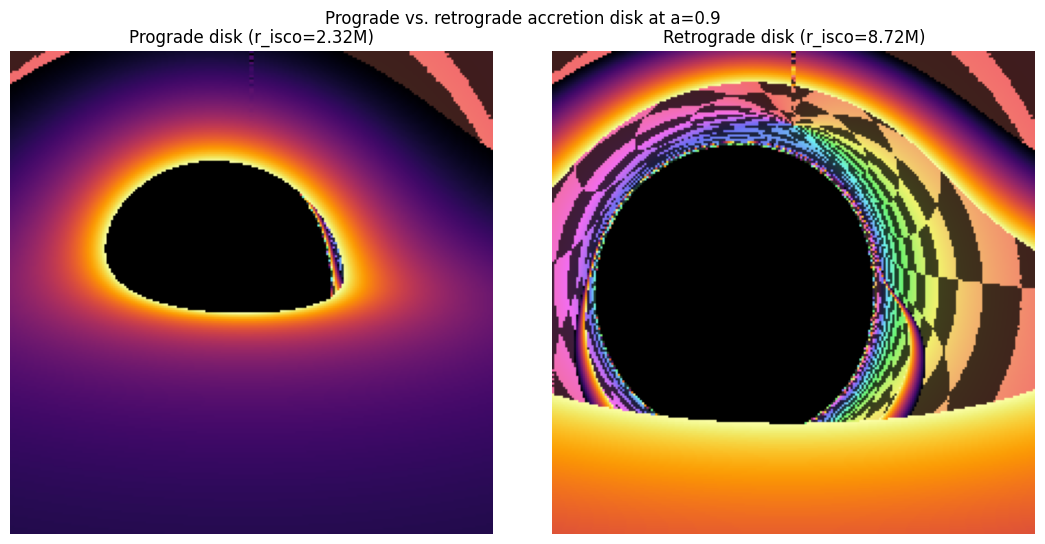

In [5]:
res_pro_retro = (220, 220)
theta_cam_pr = np.radians(75)
r_cam_pr = 16.0

imgs_pr = {}
for prograde in [True, False]:
    r_isco_pr = metric.r_isco(a_disk, M, prograde=prograde)
    t0 = time.time()
    img = raytrace.render_fast(res_pro_retro, r_cam_pr, theta_cam_pr, 0.0, a_disk,
                                disk=True, fov_deg=55.0, prograde_disk=prograde, tau_max=150.0)
    imgs_pr[prograde] = (img, r_isco_pr)
    print(f"prograde={prograde}: r_isco={r_isco_pr:.3f}M, rendered in {time.time()-t0:.1f}s")

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
for ax, prograde in zip(axes, [True, False]):
    img, r_isco_pr = imgs_pr[prograde]
    ax.imshow(img)
    ax.axis("off")
    label = "Prograde" if prograde else "Retrograde"
    ax.set_title(f"{label} disk (r_isco={r_isco_pr:.2f}M)")
fig.suptitle(f"Prograde vs. retrograde accretion disk at a={a_disk}")
fig.tight_layout()
fig.savefig(os.path.join(MEDIA, "prograde_vs_retrograde.png"), dpi=150, bbox_inches="tight")
plt.show()